In [2]:
import Symbolics as Sym
using Statistics
using Combinatorics
using DataFrames
using Plots
using Latexify

import probability: prob, event_occurency, datas

# Random Thoughts on Random Walks

## Lecture 4

Life, of course, is the source of most mathematical ideas. We look at
things that happen in the world, and then we try to abstract from those
some principles that become the mathematics that we’re trying to
develop. This is certainly true in the case of talking about probability
and randomness.

In [87]:
Sym.@variables a b P E Q Ω; #use sets for events and prob space omega

### A random walk.

You take out a
coin and ip it. If it is heads, you walk one block north; if tails, one block
south. At each block, you make that random choice. The path you take is
called a random walk.

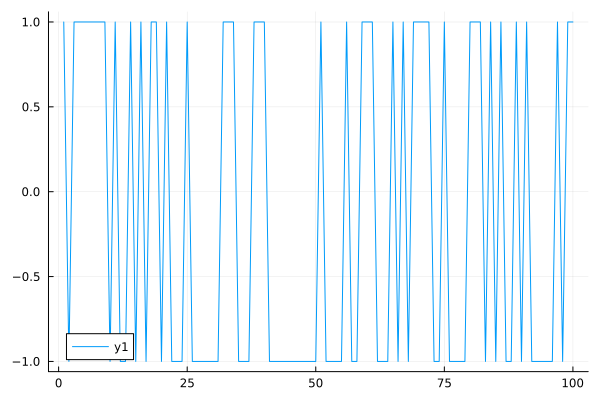

In [4]:
walks = [c == 'H' ? 1 : -1 for c in rand(datas.Coin, 100)]
plot(walks)

We add some uncertainty to our walk and ponder the question!

Will you ever venture 100 blocks away? 

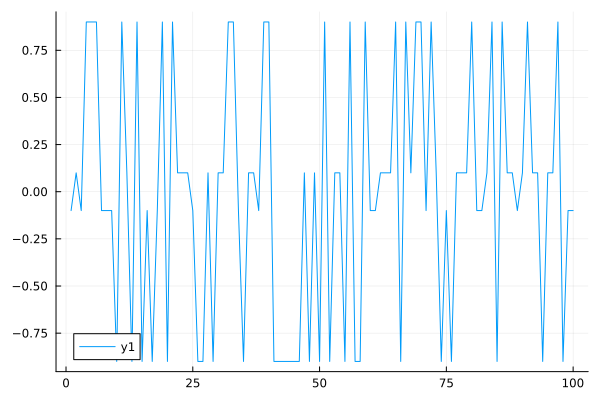

In [5]:
noise = rand(-.1:1.100, 100)
plot(walks .* noise)

You might also
ask, when we take a random walk, what is the probability that, from position
1, we will return to where we started.
To answer that question, we can compute as follows: $P = (1/2) + (1/2)Q$

In [6]:
ƒ(E=1) = (E/2) + (E/2)Q
ƒ()

0.5 + 0.5Q

Working out the equation leads to the result $P = 1$; the probability is 100%
that we will indeed return to 0.

In [7]:
P ~ ƒ() ~ 1//2 + 1//2 * Q ~ 1//2 + 1//2 * P^2

P ~ 0.5 + 0.5Q ~ (1//2) + (1//2)*Q ~ (1//2) + (1//2)*(P^2)

Another question is: What is
the probability that we will eventually get 100 blocks away from where we
started? The surprising answer is again $P = 1$.

### **The gambler’s ruin** is a variation of a random walk.

A gambler starts with
$2000. Each bet is $200, with even odds. Let’s say the game involves ipping
a coin, with heads meaning the gambler wins and tails meaning the gambler
loses.

In [8]:
2000//200 # this is how many times the gambler can bett with the ammount mention above.

10//1

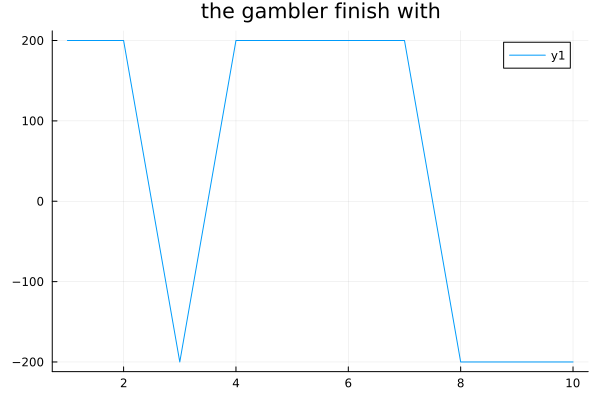

In [9]:
flips = [c == 'H' ? 200 : -200 for c in rand(datas.Coin, 10)]
plot(flips, title= "the gambler finish with")

**This means that the gambler will eventually lose
everything, even in a fair casino.**

So lets give him an equaly change to losse or get extra 200$.

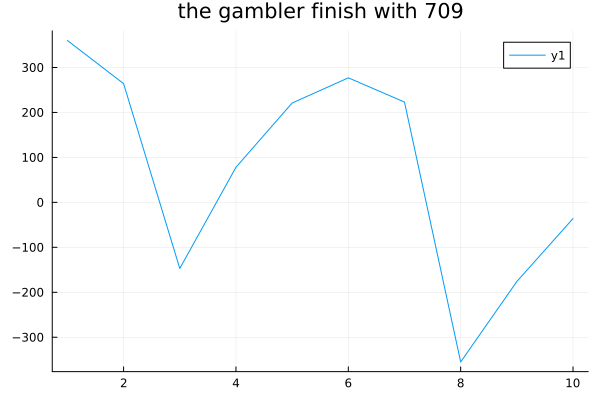

In [10]:
bettings = rand(.-200:200, 10) + flips
plot(bettings, title= "the gambler finish with $(sum(bettings))")

### Bertrand’s ballot theorem.
election between two candidates in
which the winner A, receives a votes, and the loser, B, receives b votes,
where a (52) is greater than b (47).


In [110]:
votes = [c == 'H' ? 1 : -1 for c in rand(datas.Coin, 15)]
A(voted = 52) = map(v -> v == 1 ? 1+voted : voted-1, votes)
B(voted=47) = map(v -> v == -1 ? 1+voted : voted-1, votes)
#election = map(v -> (:A => v == 1 ? 1+A : A-1, :B => v == -1 ? 1+B : B-1), votes)
election_df = DataFrame(A = A(), B = B())
election_df[1:10, :]

Row,A,B
,Int64,Int64
1,53,46
2,51,48
3,51,48
4,53,46
5,53,46
6,53,46
7,53,46
8,51,48
9,51,48


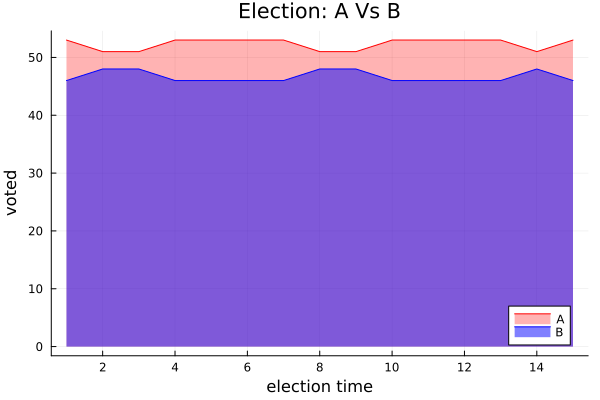

In [ ]:
areaplot(1:15, [election_df.A, election_df.B], seriescolor = [:red :blue], label=["A" "B"], 
title="Election: A Vs B", xlabel="election time", ylabel="voted", fillalpha = [0.3 0.5])

This problem can be rephrased as a graphical problem. Consider the graph
whose horizontal axis is time (or ballot number) and whose vertical axis is the
amount by which the eventual winner is ahead. The answer to the question of
what the probability is that the eventual winner will always be ahead, from
the very rst vote counted, turns out to be

In [112]:
(a - b)/(a + b)

(a - b) / (a + b)

### This discussion brings up the question of potential ties.

Suppose you wish to
hire a tennis pro. Two candidates have played one match against each other
each day for the past year, keeping a running tally of how many matches
each has won.

In [153]:
rand(1,360)

1×360 Matrix{Float64}:
 0.834993  0.607919  0.493572  0.163587  …  0.64708  0.320182  0.824155

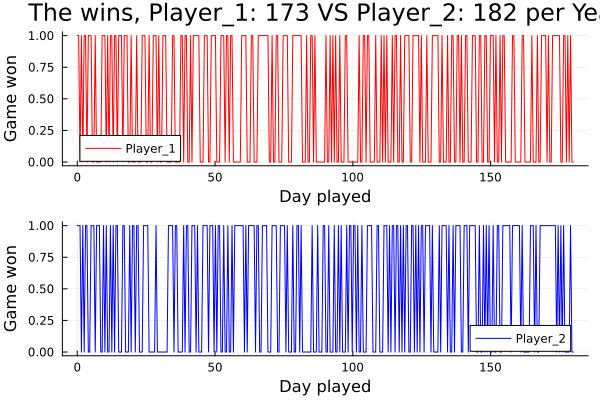

In [176]:
player_1 = [c == 'H' ? 1 : 0 for c in rand(datas.Coin, 360)]
player_2 = [c == 'H' ? 1 : 0 for c in rand(datas.Coin, 360)]
x_values = range(0, 180, length=360)

plot(x_values, [player_1, player_2], layout=(2, 1), seriescolor = [:red :blue], label=["Player_1" "Player_2"], 
xlabel="Day played", ylabel="Game won", plot_grid_title= "The wins, Player_1: $(sum(Player_1)) VS Player_2: $(sum(Player_2)) per Year")


**The tally shows that one player was ahead for the entire last nine months, so that player seems to be better.**

By comparing this situation
with randomness, we can test the strength of that conclusion. Knowing what
to expect from randomness informs our interpretation of the results.

### A 3D random walk:

If our case were expanded to north-south-
east-west, then we would have a two-
dimensional random walk.

In [189]:
X = [c == 'H' ? 1 : 0 for c in rand(datas.Coin, 500)]
Y = [c == 'H' ? 1 : 0 for c in rand(datas.Coin, 500)]
Z = [c == 'H' ? 1 : 0 for c in rand(datas.Coin, 500)];

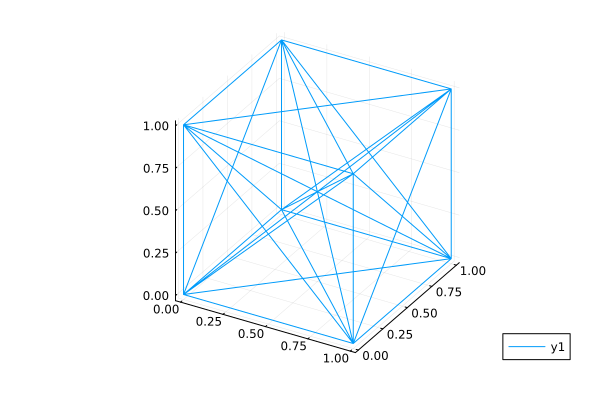

In [198]:
plot(X, Y, Z)

As with a one-dimensional random walk, the probability of returning is 1. However, the
rate at which we return is not so quick.